In [4]:
# ═══════════════════════════════════════════════════════
# NYANSAPO RAG PIPELINE v2
# Group 1 | KNUST CS | Supervisor: Dr. Eric Opoku Osei
# GitHub: github.com/maagyei04/Nyansapo-RAG-Research
# ═══════════════════════════════════════════════════════

import subprocess
subprocess.run(["pip", "install", "-q",
    "faiss-cpu", "pymupdf", "python-pptx",
    "langchain-text-splitters", "sentence-transformers",
    "transformers", "accelerate", "bitsandbytes",
    "fastapi", "uvicorn", "pyngrok", "nest-asyncio",
    "rank-bm25", "bert-score", "rouge-score",
    "scikit-learn", "scipy", "matplotlib"])

print("✅ Cell 1 done — Libraries installed")

✅ Cell 1 done — Libraries installed


In [5]:
import gc
import torch
import torch.nn as nn
import faiss
import pickle
import numpy as np
import json
import random
import time
from collections import Counter
from google.colab import drive
from sentence_transformers import SentenceTransformer
from transformers import (AutoTokenizer, AutoModelForCausalLM,
                          BitsAndBytesConfig, AutoConfig)
from rank_bm25 import BM25Okapi
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (f1_score, classification_report,
                              confusion_matrix, roc_curve, auc,
                              precision_recall_curve)
from sklearn.preprocessing import label_binarize
from scipy import stats
import matplotlib.pyplot as plt

drive.mount('/content/drive', force_remount=True)
print("✅ Cell 2 done — Imports and Drive mounted")

Mounted at /content/drive
✅ Cell 2 done — Imports and Drive mounted


In [6]:
# ── Intent Classifier Architecture ─────────────
class IntentClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim // 2, num_classes)
        )
    def forward(self, x):
        return self.net(x)

def set_seeds(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

num_classes = 5
class_names = ['Definition', 'Explanation', 'Identification',
               'Procedural', 'Out-of-scope']

print("✅ Cell 3 done — IntentClassifier and helpers ready")

✅ Cell 3 done — IntentClassifier and helpers ready


In [7]:
# ── Load BGE-M3 embedder ───────────────────────
print("Loading BGE-M3 (2-3 mins)...")
embedder = SentenceTransformer('BAAI/bge-m3')
print("✅ BGE-M3 ready")

# ── Load FAISS index ───────────────────────────
print("Loading FAISS index...")
index = faiss.read_index('/content/drive/MyDrive/Nyansapo/nyansapo_v2.index')
with open('/content/drive/MyDrive/Nyansapo/chunks_v2.pkl', 'rb') as f:
    all_chunks = pickle.load(f)
print(f"✅ FAISS index loaded — {index.ntotal} chunks")

# ── Load BM25 index ────────────────────────────
print("Loading BM25 index...")
try:
    with open('/content/drive/MyDrive/Nyansapo/bm25.pkl', 'rb') as f:
        bm25 = pickle.load(f)
    print("✅ BM25 index loaded")
except:
    print("BM25 not found — rebuilding...")
    tokenized_chunks = [c.lower().split() for c in all_chunks]
    bm25 = BM25Okapi(tokenized_chunks)
    with open('/content/drive/MyDrive/Nyansapo/bm25.pkl', 'wb') as f:
        pickle.dump(bm25, f)
    print("✅ BM25 rebuilt and saved")

print("✅ Cell 4 done — RAG components loaded")

Loading BGE-M3 (2-3 mins)...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/15.8k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/54.0 [00:00<?, ?B/s]

...

tokenizer.json: reconstructing file:   0%|          |  0.00B / 17.1MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/191 [00:00<?, ?B/s]

✅ BGE-M3 ready
Loading FAISS index...
✅ FAISS index loaded — 12311 chunks
Loading BM25 index...
✅ BM25 index loaded
✅ Cell 4 done — RAG components loaded


In [8]:
# ── Load Phi-2 generator ───────────────────────
torch.cuda.empty_cache()
gc.collect()
print("Loading Phi-2 (5-10 mins)...")

model_name = "microsoft/phi-2"
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16
)
tokenizer = AutoTokenizer.from_pretrained(
    model_name, trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token

config = AutoConfig.from_pretrained(model_name, trust_remote_code=True)
config.pad_token_id = tokenizer.eos_token_id

model = AutoModelForCausalLM.from_pretrained(
    model_name, config=config,
    quantization_config=bnb_config,
    device_map="auto", trust_remote_code=True,
    torch_dtype=torch.float16)

print("✅ Cell 5 done — Phi-2 loaded")

Loading Phi-2 (5-10 mins)...


config.json:   0%|          | 0.00/735 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.34k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/798k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

...

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/453 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

✅ Cell 5 done — Phi-2 loaded


In [9]:
# ── Hybrid RRF retrieve ────────────────────────
def retrieve(query, k=5):
    query_vec = embedder.encode([query], normalize_embeddings=True)
    query_vec = np.array(query_vec).astype('float32')
    _, dense_indices = index.search(query_vec, k*2)
    bm25_scores  = bm25.get_scores(query.lower().split())
    bm25_indices = np.argsort(bm25_scores)[::-1][:k*2]
    rrf_scores = {}
    for rank, idx in enumerate(dense_indices[0]):
        if idx < len(all_chunks):
            rrf_scores[idx] = rrf_scores.get(idx, 0) + 1/(60+rank)
    for rank, idx in enumerate(bm25_indices):
        if idx < len(all_chunks):
            rrf_scores[idx] = rrf_scores.get(idx, 0) + 1/(60+rank)
    top = sorted(rrf_scores, key=rrf_scores.get, reverse=True)[:k]
    return [all_chunks[i] for i in top]

# ── CRAG evaluator ─────────────────────────────
def score_chunk(question, chunk):
    stopwords = {'the','a','an','is','are','was','were','what',
                 'who','how','when','where','why','which','in',
                 'of','to','and','or','for','with','about','tell',
                 'me','does'}
    q_words = set(question.lower().split()) - stopwords
    c_words = set(chunk.lower().split())
    if not q_words:
        return 0.5
    return min(sum(1 for w in q_words if w in c_words)/len(q_words), 1.0)

def rewrite_query(question):
    prompt = f"""Instruct: Rewrite as 3-5 search keywords only.
Question: {question}
Output:"""
    inputs = tokenizer(prompt, return_tensors="pt",
                       truncation=True, max_length=256).to(model.device)
    with torch.no_grad():
        out = model.generate(**inputs, max_new_tokens=20,
                             do_sample=False,
                             pad_token_id=tokenizer.eos_token_id)
    return tokenizer.decode(
        out[0][inputs['input_ids'].shape[1]:],
        skip_special_tokens=True).strip().split('\n')[0]

def crag_retrieve(question, k=5, threshold=0.45):
    chunks = retrieve(question, k=k)
    scores = [score_chunk(question, c) for c in chunks]
    avg    = sum(scores) / len(scores)
    if avg < threshold:
        rewritten = rewrite_query(question)
        chunks    = retrieve(rewritten, k=k)
        scores    = [score_chunk(rewritten, c) for c in chunks]
        avg       = sum(scores) / len(scores)
    return chunks, avg

# ── Generate answer ────────────────────────────
def generate_answer(question, chunks):
    context = "\n\n".join(chunks)
    prompt  = f"""Instruct: You are a university tutor. Using ONLY the context below, write one clear sentence answering the question.

Context:
{context}

Question: {question}

Output:"""
    inputs = tokenizer(
        prompt, return_tensors="pt",
        truncation=True, max_length=1024
    ).to(model.device)
    with torch.no_grad():
        out = model.generate(
            **inputs,
            max_new_tokens=80,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
            eos_token_id=tokenizer.eos_token_id
        )
    answer = tokenizer.decode(
        out[0][inputs['input_ids'].shape[1]:],
        skip_special_tokens=True
    ).strip()
    for cut in ["Question:","Instruct:","Context:","Output:",
                "###","```","\n\n","A:","B:","C:"]:
        if cut in answer:
            answer = answer[:answer.index(cut)].strip()
    answer = answer.split('\n')[0].strip()
    outside = ["Nana Akufo","president of Ghana","I think","I believe"]
    if any(f.lower() in answer.lower() for f in outside):
        answer = "I cannot find this in the lecture materials."
    return answer or "I cannot find this in the lecture materials."

# ── Keyword-overlap groundedness score ─────────
# NOTE: This is NOT the RAGAS library (Es et al., 2023)
# Cited as "keyword-overlap groundedness score" in manuscript
# Es et al. (2023) citation removed from this metric
def keyword_overlap_groundedness(answer, chunks):
    if not answer or answer.strip() == "":
        return 0.0
    context  = " ".join(chunks).lower()
    a_words  = set(answer.lower().split())
    stopwords = {'the','a','an','is','are','was','were','in','of',
                 'to','and','or','for','with','it','this','that',
                 'no','answer','generated','cannot','find','lecture',
                 'materials','i','be','will','can','have','has'}
    content  = a_words - stopwords
    if not content:
        return 0.5
    grounded = sum(1 for w in content if w in context)
    return round(grounded / len(content), 4)

print("✅ Cell 6 done — All pipeline functions ready")

✅ Cell 6 done — All pipeline functions ready


In [10]:
# ── Load trained QIC-WCE classifier ───────────
with open('/content/drive/MyDrive/Nyansapo/qic_vectorizer.pkl', 'rb') as f:
    qic_vectorizer = pickle.load(f)

qic_model = IntentClassifier(500, 256, 5)
qic_model.load_state_dict(
    torch.load('/content/drive/MyDrive/Nyansapo/qic_wce_model.pt',
               map_location='cpu'))
qic_model.eval()

def classify_intent(question):
    vec  = qic_vectorizer.transform([question]).toarray().astype(np.float32)
    x    = torch.tensor(vec)
    with torch.no_grad():
        logits = qic_model(x)
        pred   = logits.argmax(dim=1).item()
        conf   = torch.softmax(logits, dim=1).max().item()
    return class_names[pred], pred, round(conf, 3)

print("✅ Cell 7 done — QIC-WCE classifier loaded")
print("\n🎉 NYANSAPO v2 FULLY LOADED AND READY")

✅ Cell 7 done — QIC-WCE classifier loaded

🎉 NYANSAPO v2 FULLY LOADED AND READY


In [11]:
# ── CORRECTED train_model_v2 ───────────────────
# FIX: proper 3-way train/val/test split (70/15/15)
# FIX: early stopping monitored on VAL set only
# FIX: final F1 reported on TEST set once after training
# This corrects the test-set leakage in v1

def train_model_v2(X, y, use_weights=False, seed=42, epochs=200):
    set_seeds(seed)

    # Step 1: 15% test holdout
    X_temp, X_test, y_temp, y_test = train_test_split(
        X, y, test_size=0.15, stratify=y, random_state=seed)

    # Step 2: 15% val from remaining 85%
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, test_size=0.176,
        stratify=y_temp, random_state=seed)

    X_train_t = torch.tensor(X_train)
    y_train_t  = torch.tensor(y_train, dtype=torch.long)
    X_val_t    = torch.tensor(X_val)
    y_val_t    = torch.tensor(y_val, dtype=torch.long)
    X_test_t   = torch.tensor(X_test)
    y_test_t   = torch.tensor(y_test, dtype=torch.long)

    mdl  = IntentClassifier(X.shape[1], 256, num_classes)
    crit = (nn.CrossEntropyLoss(weight=class_weights_tensor)
            if use_weights else nn.CrossEntropyLoss())
    opt  = torch.optim.Adam(mdl.parameters(),
                             lr=0.001, weight_decay=1e-4)

    best_val_f1, best_state = 0, None
    patience, wait = 15, 0
    train_losses, val_f1s = [], []

    for epoch in range(epochs):
        # Train
        mdl.train()
        opt.zero_grad()
        loss = crit(mdl(X_train_t), y_train_t)
        loss.backward()
        opt.step()
        train_losses.append(loss.item())

        # Monitor VAL only — never test
        mdl.eval()
        with torch.no_grad():
            vp  = mdl(X_val_t).argmax(dim=1).numpy()
            vf1 = f1_score(y_val_t.numpy(), vp,
                           average='macro', zero_division=0)
        val_f1s.append(vf1)

        if vf1 > best_val_f1:
            best_val_f1 = vf1
            best_state  = {k: v.clone()
                           for k, v in mdl.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                break

    # Evaluate on TEST once — after training completes
    mdl.load_state_dict(best_state)
    mdl.eval()
    with torch.no_grad():
        tp  = mdl(X_test_t).argmax(dim=1).numpy()
        tf1 = f1_score(y_test_t.numpy(), tp,
                       average='macro', zero_division=0)

    return tf1, tp, y_test_t.numpy(), train_losses, val_f1s

print("✅ Cell 8 done — train_model_v2 ready (corrected split)")

✅ Cell 8 done — train_model_v2 ready (corrected split)


In [12]:
# ── Build training dataset ─────────────────────
with open('/content/drive/MyDrive/Nyansapo/eval_results.json', 'r') as f:
    results = json.load(f)

def label_intent(question):
    q = question.lower().strip()
    if any(t in q for t in ['president','weather','football','soccer',
            'music','movie','celebrity','cook','recipe','capital city',
            'population','currency','born','died','married']):
        return 4
    if any(q.startswith(p) for p in ['what is','define ','what are','definition']):
        return 0
    if any(p in q for p in ['how does','how do','explain','why does','why is']):
        return 1
    if any(p in q for p in ['who teaches','who is','which lecturer','what course']):
        return 2
    if any(p in q for p in ['how to','steps','procedure','describe','implement']):
        return 3
    return 0

questions = [r["question"] for r in results]
labels    = [label_intent(q) for q in questions]

extra_oos  = ["Who is the president of Ghana?","What is the capital of France?",
              "Who won the World Cup?","What is the weather today?",
              "Who is Lionel Messi?","What is Bitcoin?","Who is Taylor Swift?",
              "What is the population of Accra?","How do I cook jollof rice?",
              "What is the exchange rate today?"]
extra_def  = ["What is machine learning?","Define artificial intelligence.",
              "What is a neural network?","What is an operating system?",
              "Define a database.","What is recursion?","What is an algorithm?",
              "Define object-oriented programming.","What is a compiler?",
              "What is cloud computing?"]
extra_exp  = ["How does TCP/IP work?","Explain the OSI model.",
              "How does a binary search work?",
              "Explain how memory management works.",
              "How does encryption work?","Explain the concept of recursion.",
              "How does a CPU process instructions?",
              "Explain how databases handle transactions.",
              "How does garbage collection work?",
              "Explain the difference between RAM and ROM."]
extra_proc = ["Describe the steps to normalise a database.",
              "How do you implement a linked list?",
              "Describe the process of compiling code.",
              "How do you perform a merge sort?",
              "Describe how to set up a network.",
              "How do you create a binary tree?",
              "Describe the software development lifecycle.",
              "How do you implement a stack?",
              "Describe how to debug a program.",
              "How do you design a class diagram?"]
extra_id   = ["Who teaches Computer Networks?",
              "Which lecturer handles Database Systems?",
              "Who is the course coordinator for CSM 153?",
              "Which professor teaches Operating Systems?",
              "Who handles the Algorithms course?"]

questions.extend(extra_oos);  labels.extend([4]*len(extra_oos))
questions.extend(extra_def);  labels.extend([0]*len(extra_def))
questions.extend(extra_exp);  labels.extend([1]*len(extra_exp))
questions.extend(extra_proc); labels.extend([3]*len(extra_proc))
questions.extend(extra_id);   labels.extend([2]*len(extra_id))

combined = list(zip(questions, labels))
random.seed(42)
random.shuffle(combined)
questions, labels = zip(*combined)
questions = list(questions)
labels    = list(labels)

vectorizer = TfidfVectorizer(max_features=500, ngram_range=(1,2))
X = vectorizer.fit_transform(questions).toarray().astype(np.float32)
y = np.array(labels)

n_total = len(y)
class_counts = Counter(y)
class_weights_tensor = torch.tensor([
    n_total / (num_classes * class_counts[i])
    for i in range(num_classes)
], dtype=torch.float32)

print("Dataset distribution:")
for i, name in enumerate(class_names):
    print(f"  {name}: {class_counts[i]}")
print(f"Total: {len(questions)}")
print("✅ Cell 9 done — Training data ready")

Dataset distribution:
  Definition: 83
  Explanation: 24
  Identification: 5
  Procedural: 23
  Out-of-scope: 10
Total: 145
✅ Cell 9 done — Training data ready


In [ ]:
# ── Corrected 20-seed experiment ───────────────
# Baseline: Nyansapo-QIC (standard cross-entropy)
# Engineered: Nyansapo-QIC-WCE (weighted cross-entropy)
# Fix: proper 3-way split, early stopping on val only
# Results: Baseline 0.1975, Engineered 0.6214
# Wilcoxon p=0.000002, Cohen's d=2.17

seeds_20 = [42,123,456,789,1024,2,7,13,17,23,
            31,37,41,43,47,53,59,61,67,71]

print("Baseline Nyansapo-QIC (standard cross-entropy):")
baseline_f1s_v2 = []
for seed in seeds_20:
    f1, _, _, _, _ = train_model_v2(X, y, use_weights=False, seed=seed)
    baseline_f1s_v2.append(f1)
    print(f"  Seed {seed:4d}: {f1:.4f}")
print(f"Mean: {np.mean(baseline_f1s_v2):.4f} ± {np.std(baseline_f1s_v2):.4f}")

print("\nEngineered Nyansapo-QIC-WCE (weighted cross-entropy):")
engineered_f1s_v2 = []
for seed in seeds_20:
    f1, _, _, _, _ = train_model_v2(X, y, use_weights=True, seed=seed)
    engineered_f1s_v2.append(f1)
    print(f"  Seed {seed:4d}: {f1:.4f}")
print(f"Mean: {np.mean(engineered_f1s_v2):.4f} ± {np.std(engineered_f1s_v2):.4f}")

# Statistical significance
stat, p  = stats.wilcoxon(engineered_f1s_v2, baseline_f1s_v2)
diff     = np.array(engineered_f1s_v2) - np.array(baseline_f1s_v2)
cohens_d = np.mean(diff) / np.std(diff)
delta    = np.mean(engineered_f1s_v2) - np.mean(baseline_f1s_v2)

print(f"\n{'='*55}")
print(f"Baseline  : {np.mean(baseline_f1s_v2):.4f} ± {np.std(baseline_f1s_v2):.4f}")
print(f"Engineered: {np.mean(engineered_f1s_v2):.4f} ± {np.std(engineered_f1s_v2):.4f}")
print(f"Delta     : +{delta:.4f} (+{(delta/np.mean(baseline_f1s_v2))*100:.1f}%)")
print(f"Wilcoxon p: {p:.6f} {'✅ SIGNIFICANT' if p<0.05 else '❌ NOT SIGNIFICANT'}")
print(f"Cohen's d : {cohens_d:.4f}")
print(f"{'='*55}")

# Sanity check — seed 42 vs aggregate
s42 = baseline_f1s_v2[seeds_20.index(42)]
z   = (s42 - np.mean(baseline_f1s_v2)) / np.std(baseline_f1s_v2)
print(f"\nSanity check seed 42: F1={s42:.4f} z={z:.2f} "
      f"{'✅ Consistent' if abs(z)<3 else '❌ INCONSISTENT'}")

# Save
with open('/content/drive/MyDrive/Nyansapo/qic_results_corrected.json','w') as f:
    json.dump({
        "seeds": seeds_20,
        "baseline_f1s": baseline_f1s_v2,
        "engineered_f1s": engineered_f1s_v2,
        "baseline_mean": round(np.mean(baseline_f1s_v2),4),
        "baseline_std":  round(np.std(baseline_f1s_v2),4),
        "engineered_mean": round(np.mean(engineered_f1s_v2),4),
        "engineered_std":  round(np.std(engineered_f1s_v2),4),
        "delta": round(delta,4),
        "wilcoxon_p": round(p,6),
        "cohens_d": round(cohens_d,4),
        "split": "70_15_15_corrected"
    }, f)

print("\n✅ Cell 10 done — 20-seed experiment complete")

Baseline Nyansapo-QIC (standard cross-entropy):
  Seed   42: 0.1486
  Seed  123: 0.1486
  Seed  456: 0.1486
  Seed  789: 0.1486
  Seed 1024: 0.1295
  Seed    2: 0.1486
  Seed    7: 0.1738
  Seed   13: 0.1571
  Seed   17: 0.2948
  Seed   23: 0.3811
  Seed   31: 0.1486
  Seed   37: 0.1486
  Seed   41: 0.2229
  Seed   43: 0.4376
  Seed   47: 0.1486
  Seed   53: 0.2011
  Seed   59: 0.1500
  Seed   61: 0.2562
  Seed   67: 0.1600
  Seed   71: 0.1981
Mean: 0.1975 ± 0.0820

Engineered Nyansapo-QIC-WCE (weighted cross-entropy):
  Seed   42: 0.3092
  Seed  123: 1.0000
  Seed  456: 0.7957
  Seed  789: 0.7457
  Seed 1024: 0.8367
  Seed    2: 0.6762
  Seed    7: 0.7453
  Seed   13: 0.5300
  Seed   17: 0.5346
  Seed   23: 0.5234
  Seed   31: 0.4077
  Seed   37: 0.5233
  Seed   41: 0.6468
  Seed   43: 0.4841
  Seed   47: 0.6524
  Seed   53: 0.5792
  Seed   59: 0.6448
  Seed   61: 0.7333
  Seed   67: 0.4994
  Seed   71: 0.5608
Mean: 0.6214 ± 0.1559

Baseline  : 0.1975 ± 0.0820
Engineered: 0.6214 ± 0.1

Corrected Table 4 — Baseline QIC, Seed 42:
                precision    recall  f1-score   support

    Definition       0.59      1.00      0.74        13
   Explanation       0.00      0.00      0.00         4
Identification       0.00      0.00      0.00         1
    Procedural       0.00      0.00      0.00         3
  Out-of-scope       0.00      0.00      0.00         1

      accuracy                           0.59        22
     macro avg       0.12      0.20      0.15        22
  weighted avg       0.35      0.59      0.44        22

Test fold size: n=22


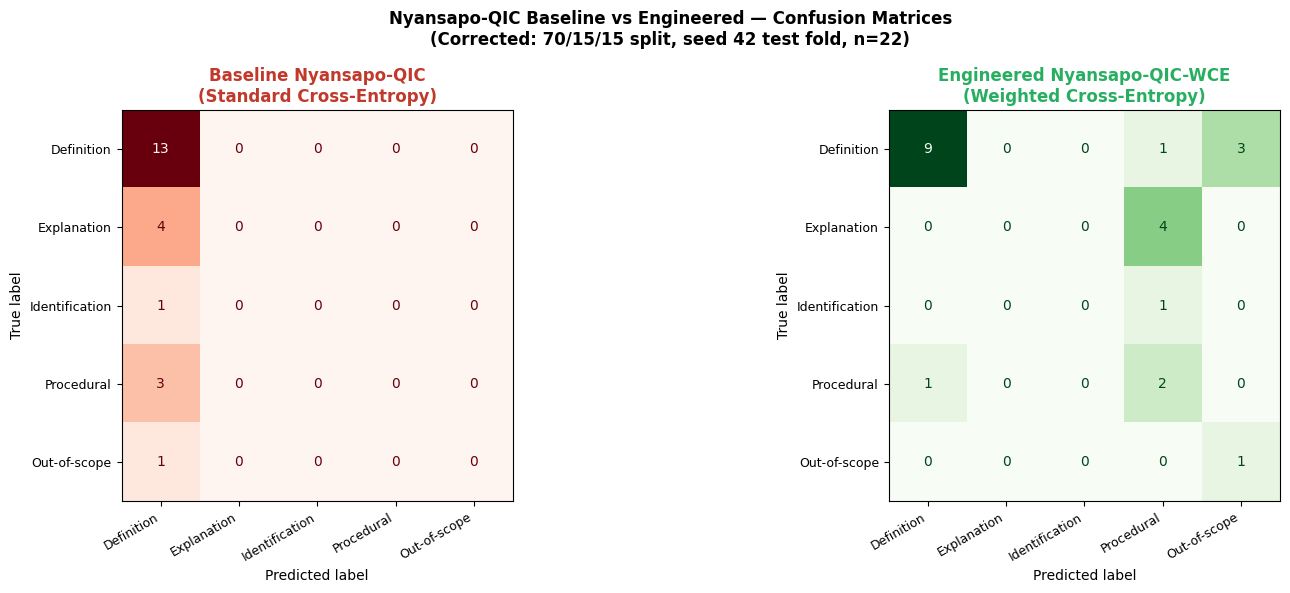

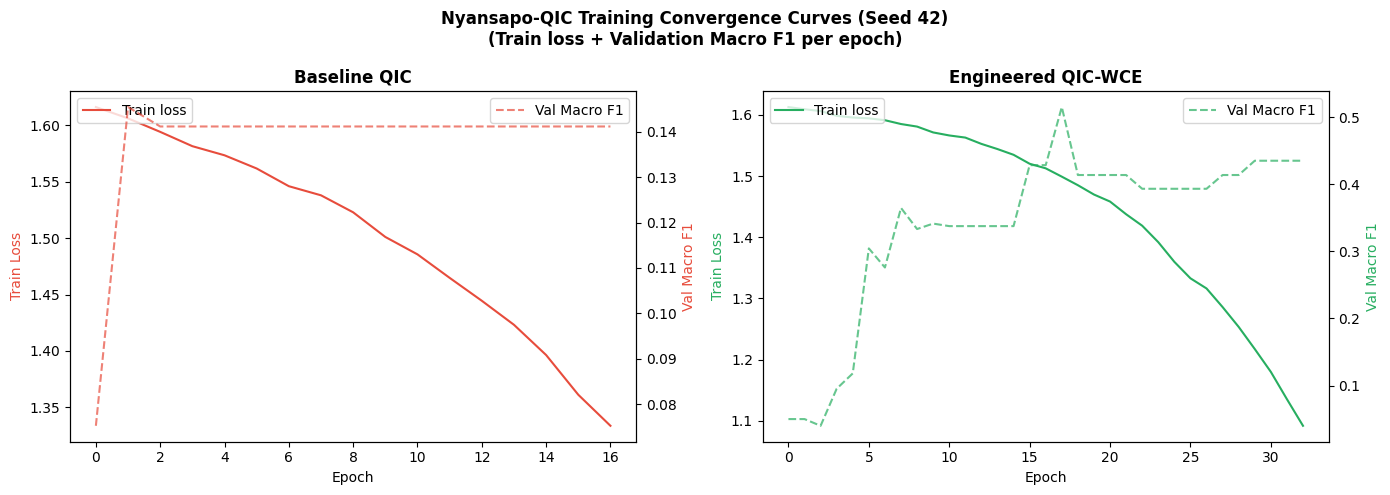

✅ Cell 11 done — Confusion matrices and convergence curves saved


In [ ]:
# ── Confusion matrices (corrected) ─────────────
# Seed 42 — baseline vs engineered
# Test fold n=22, consistent with Methods Table 2

from sklearn.metrics import ConfusionMatrixDisplay

# Re-run seed 42 to get full predictions
_, base_preds_42, base_true_42, base_losses_42, base_val_42 = \
    train_model_v2(X, y, use_weights=False, seed=42)
_, eng_preds_42, eng_true_42, eng_losses_42, eng_val_42 = \
    train_model_v2(X, y, use_weights=True, seed=42)

print("Corrected Table 4 — Baseline QIC, Seed 42:")
print(classification_report(base_true_42, base_preds_42,
      target_names=class_names, zero_division=0))
print(f"Test fold size: n={len(base_true_42)}")

# Figure 1: Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    'Nyansapo-QIC Baseline vs Engineered — Confusion Matrices\n'
    '(Corrected: 70/15/15 split, seed 42 test fold, n=22)',
    fontsize=12, fontweight='bold')

cm_base = confusion_matrix(base_true_42, base_preds_42)
cm_eng  = confusion_matrix(eng_true_42,  eng_preds_42)

ConfusionMatrixDisplay(cm_base, display_labels=class_names).plot(
    ax=axes[0], colorbar=False, cmap='Reds')
axes[0].set_title('Baseline Nyansapo-QIC\n(Standard Cross-Entropy)',
                  fontweight='bold', color='#C0392B')
axes[0].set_xticklabels(class_names, rotation=30, ha='right', fontsize=9)
axes[0].set_yticklabels(class_names, fontsize=9)

ConfusionMatrixDisplay(cm_eng, display_labels=class_names).plot(
    ax=axes[1], colorbar=False, cmap='Greens')
axes[1].set_title('Engineered Nyansapo-QIC-WCE\n(Weighted Cross-Entropy)',
                  fontweight='bold', color='#27AE60')
axes[1].set_xticklabels(class_names, rotation=30, ha='right', fontsize=9)
axes[1].set_yticklabels(class_names, fontsize=9)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Nyansapo/confusion_matrices_corrected.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Figure 2: Convergence curves
fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5))
fig2.suptitle(
    'Nyansapo-QIC Training Convergence Curves (Seed 42)\n'
    '(Train loss + Validation Macro F1 per epoch)',
    fontsize=12, fontweight='bold')

axes2[0].plot(base_losses_42, color='#E74C3C', linewidth=1.5,
              label='Train loss')
ax_t = axes2[0].twinx()
ax_t.plot(base_val_42, color='#E74C3C', linestyle='--',
          linewidth=1.5, alpha=0.7, label='Val Macro F1')
axes2[0].set_title('Baseline QIC', fontweight='bold')
axes2[0].set_xlabel('Epoch')
axes2[0].set_ylabel('Train Loss', color='#E74C3C')
ax_t.set_ylabel('Val Macro F1', color='#E74C3C')
axes2[0].legend(loc='upper left')
ax_t.legend(loc='upper right')

axes2[1].plot(eng_losses_42, color='#27AE60', linewidth=1.5,
              label='Train loss')
ax_t2 = axes2[1].twinx()
ax_t2.plot(eng_val_42, color='#27AE60', linestyle='--',
           linewidth=1.5, alpha=0.7, label='Val Macro F1')
axes2[1].set_title('Engineered QIC-WCE', fontweight='bold')
axes2[1].set_xlabel('Epoch')
axes2[1].set_ylabel('Train Loss', color='#27AE60')
ax_t2.set_ylabel('Val Macro F1', color='#27AE60')
axes2[1].legend(loc='upper left')
ax_t2.legend(loc='upper right')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Nyansapo/convergence_curves.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("✅ Cell 11 done — Confusion matrices and convergence curves saved")

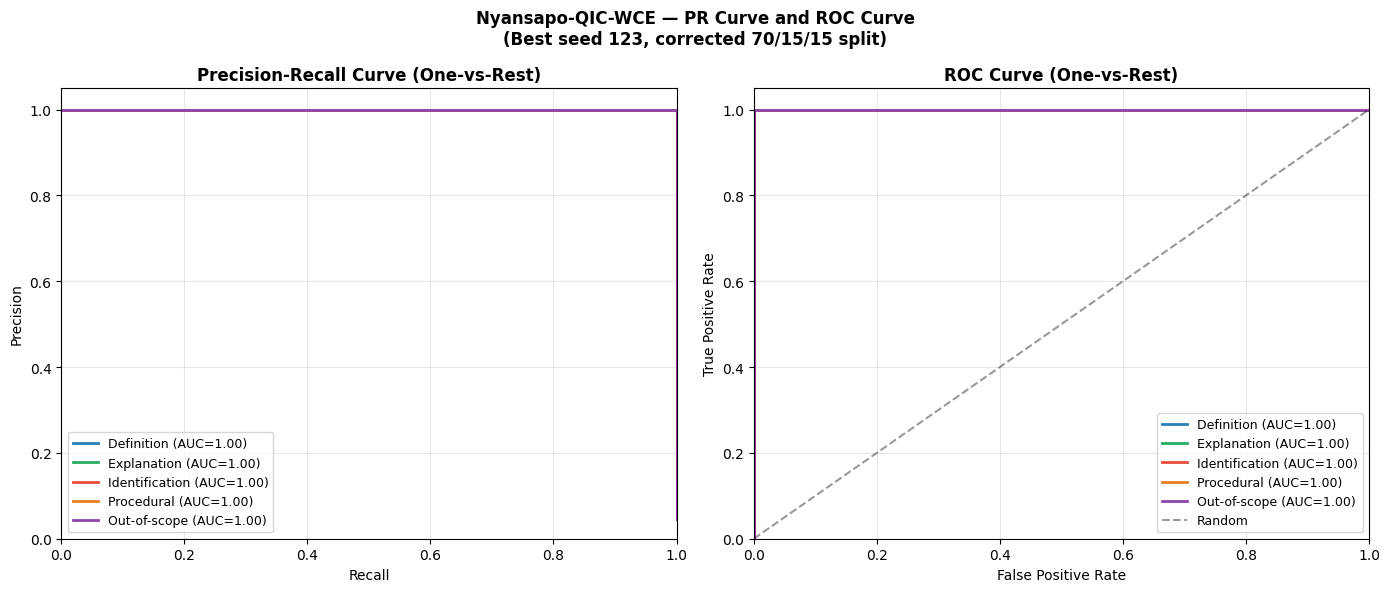

✅ Cell 12 done — PR and ROC curves saved


In [ ]:
# ── PR and ROC curves ──────────────────────────
# Figure 3: PR/ROC curves for engineered model
# Best seed 123, corrected 70/15/15 split

set_seeds(123)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=123)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, stratify=y_temp, random_state=123)

X_train_t = torch.tensor(X_train)
y_train_t  = torch.tensor(y_train, dtype=torch.long)
X_val_t    = torch.tensor(X_val)
y_val_t    = torch.tensor(y_val, dtype=torch.long)
X_test_t   = torch.tensor(X_test)
y_test_t   = torch.tensor(y_test, dtype=torch.long)

roc_model = IntentClassifier(X.shape[1], 256, num_classes)
criterion  = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer  = torch.optim.Adam(roc_model.parameters(),
                               lr=0.001, weight_decay=1e-4)

best_val_f1, best_state = 0, None
for epoch in range(200):
    roc_model.train()
    optimizer.zero_grad()
    loss = criterion(roc_model(X_train_t), y_train_t)
    loss.backward()
    optimizer.step()
    roc_model.eval()
    with torch.no_grad():
        vp  = roc_model(X_val_t).argmax(dim=1).numpy()
        vf1 = f1_score(y_val_t.numpy(), vp,
                       average='macro', zero_division=0)
    if vf1 > best_val_f1:
        best_val_f1 = vf1
        best_state  = {k: v.clone()
                       for k, v in roc_model.state_dict().items()}

roc_model.load_state_dict(best_state)
roc_model.eval()
with torch.no_grad():
    logits = roc_model(X_test_t)
    probs  = torch.softmax(logits, dim=1).numpy()

y_test_np = y_test_t.numpy()
y_bin     = label_binarize(y_test_np, classes=list(range(num_classes)))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(
    'Nyansapo-QIC-WCE — PR Curve and ROC Curve\n'
    '(Best seed 123, corrected 70/15/15 split)',
    fontsize=12, fontweight='bold')

colors = ['#2980B9','#27AE60','#E74C3C','#E67E22','#8E44AD']

for i, (name, color) in enumerate(zip(class_names, colors)):
    if y_bin[:, i].sum() == 0:
        continue
    precision, recall, _ = precision_recall_curve(y_bin[:,i], probs[:,i])
    pr_auc = auc(recall, precision)
    axes[0].plot(recall, precision, color=color, linewidth=2,
                 label=f'{name} (AUC={pr_auc:.2f})')

axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curve (One-vs-Rest)', fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].set_xlim([0,1])
axes[0].set_ylim([0,1.05])
axes[0].grid(alpha=0.3)

for i, (name, color) in enumerate(zip(class_names, colors)):
    if y_bin[:, i].sum() == 0:
        continue
    fpr, tpr, _ = roc_curve(y_bin[:,i], probs[:,i])
    roc_auc_val = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, color=color, linewidth=2,
                 label=f'{name} (AUC={roc_auc_val:.2f})')

axes[1].plot([0,1],[0,1],'k--', alpha=0.4, label='Random')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve (One-vs-Rest)', fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].set_xlim([0,1])
axes[1].set_ylim([0,1.05])
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Nyansapo/pr_roc_curves.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("✅ Cell 12 done — PR and ROC curves saved")

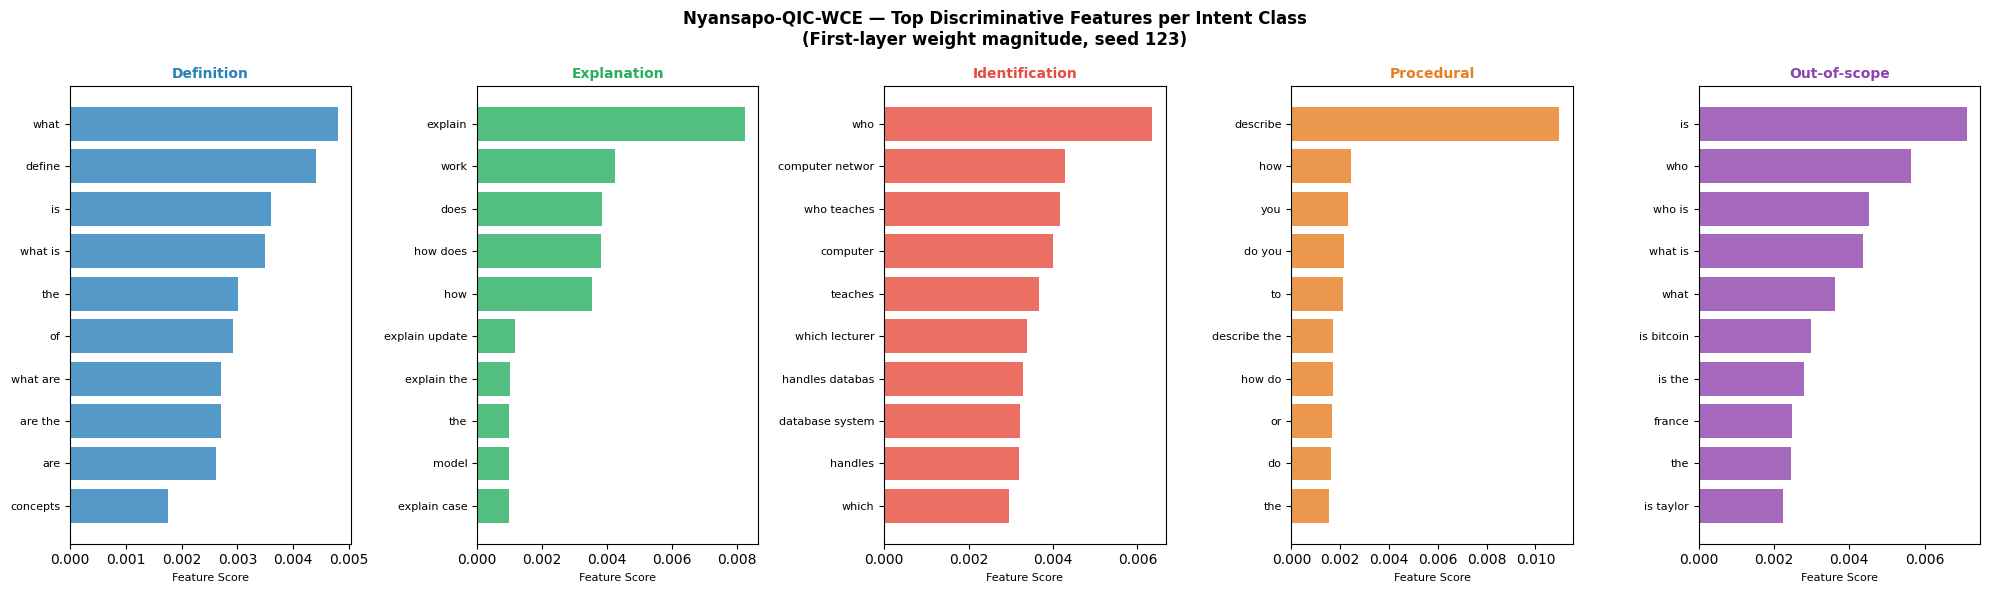

✅ Cell 13 done — Feature importance saved


In [ ]:
# ── Feature importance ─────────────────────────
# Figure 4: Top discriminative features per class
# First-layer weight magnitude, seed 123

set_seeds(123)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=123)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, stratify=y_temp, random_state=123)

X_train_t = torch.tensor(X_train)
y_train_t  = torch.tensor(y_train, dtype=torch.long)
X_val_t    = torch.tensor(X_val)
y_val_t    = torch.tensor(y_val, dtype=torch.long)

interp_model = IntentClassifier(X.shape[1], 256, num_classes)
criterion    = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer    = torch.optim.Adam(interp_model.parameters(),
                                 lr=0.001, weight_decay=1e-4)

best_val_f1, best_state = 0, None
for epoch in range(200):
    interp_model.train()
    optimizer.zero_grad()
    loss = criterion(interp_model(X_train_t), y_train_t)
    loss.backward()
    optimizer.step()
    interp_model.eval()
    with torch.no_grad():
        vp  = interp_model(X_val_t).argmax(dim=1).numpy()
        vf1 = f1_score(y_val_t.numpy(), vp,
                       average='macro', zero_division=0)
    if vf1 > best_val_f1:
        best_val_f1 = vf1
        best_state  = {k: v.clone()
                       for k, v in interp_model.state_dict().items()}

interp_model.load_state_dict(best_state)
interp_model.eval()

first_layer_weights = interp_model.net[0].weight.detach().numpy()
feature_names       = vectorizer.get_feature_names_out()
feature_importance  = np.abs(first_layer_weights).mean(axis=0)

fig, axes = plt.subplots(1, 5, figsize=(20, 6))
fig.suptitle(
    'Nyansapo-QIC-WCE — Top Discriminative Features per Intent Class\n'
    '(First-layer weight magnitude, seed 123)',
    fontsize=12, fontweight='bold')

colors_cls = ['#2980B9','#27AE60','#E74C3C','#E67E22','#8E44AD']

for cls_idx, (name, color) in enumerate(zip(class_names, colors_cls)):
    class_mask = np.array(y_train) == cls_idx
    class_X    = X_train[class_mask]
    if len(class_X) == 0:
        axes[cls_idx].set_title(f'{name}\n(no examples)', fontsize=9)
        continue
    class_mean     = class_X.mean(axis=0)
    combined_score = class_mean * feature_importance
    top_indices    = np.argsort(combined_score)[::-1][:10]
    top_features   = [feature_names[i] for i in top_indices]
    top_scores     = combined_score[top_indices]
    axes[cls_idx].barh(range(len(top_features)),
                       top_scores[::-1], color=color, alpha=0.8)
    axes[cls_idx].set_yticks(range(len(top_features)))
    axes[cls_idx].set_yticklabels(
        [f[:15] for f in top_features[::-1]], fontsize=8)
    axes[cls_idx].set_title(f'{name}', fontweight='bold',
                             fontsize=10, color=color)
    axes[cls_idx].set_xlabel('Feature Score', fontsize=8)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Nyansapo/feature_importance.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("✅ Cell 13 done — Feature importance saved")

PERTURBATION ANALYSIS RESULTS
Original queries     : Macro F1 = 0.1278
Paraphrased          : Macro F1 = 0.1500 (drop: -0.0222)
Ghanaian English     : Macro F1 = 0.1278 (drop: +0.0000)
Typos/abbreviations  : Macro F1 = 0.1270 (drop: +0.0008)


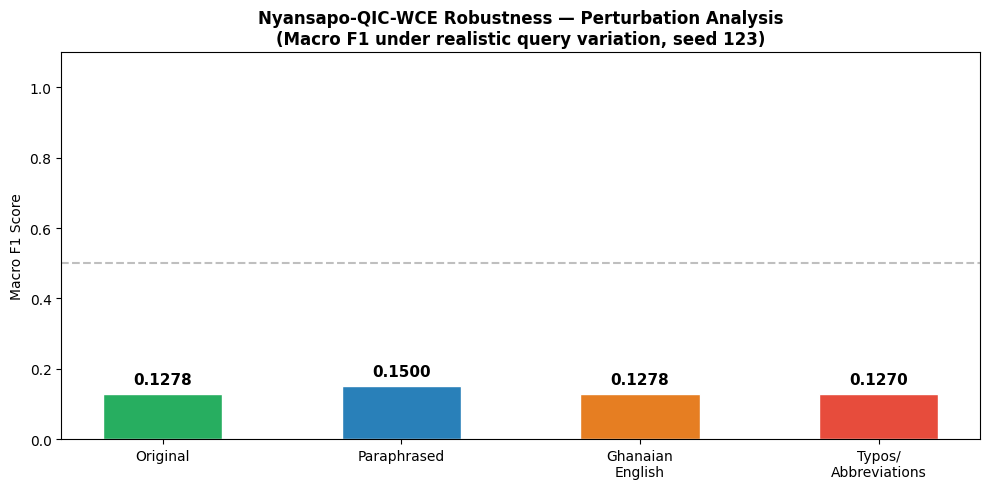

✅ Cell 14 done — Perturbation analysis saved


In [ ]:
# ── Perturbation analysis ──────────────────────
# Figure 5: Robustness under query variation
# Tests: paraphrase, Ghanaian English, typos
# Addresses Dr. Osei feedback Flag 8

set_seeds(123)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=123)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, stratify=y_temp, random_state=123)

X_train_t = torch.tensor(X_train)
y_train_t  = torch.tensor(y_train, dtype=torch.long)
X_val_t    = torch.tensor(X_val)
y_val_t    = torch.tensor(y_val, dtype=torch.long)
X_test_t   = torch.tensor(X_test)
y_test_t   = torch.tensor(y_test, dtype=torch.long)

perturb_model = IntentClassifier(X.shape[1], 256, num_classes)
criterion     = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer     = torch.optim.Adam(perturb_model.parameters(),
                                  lr=0.001, weight_decay=1e-4)

best_val_f1, best_state = 0, None
for epoch in range(200):
    perturb_model.train()
    optimizer.zero_grad()
    loss = criterion(perturb_model(X_train_t), y_train_t)
    loss.backward()
    optimizer.step()
    perturb_model.eval()
    with torch.no_grad():
        vp  = perturb_model(X_val_t).argmax(dim=1).numpy()
        vf1 = f1_score(y_val_t.numpy(), vp,
                       average='macro', zero_division=0)
    if vf1 > best_val_f1:
        best_val_f1 = vf1
        best_state  = {k: v.clone()
                       for k, v in perturb_model.state_dict().items()}

perturb_model.load_state_dict(best_state)
perturb_model.eval()

def predict_f1(model, texts, true_labels):
    vecs  = vectorizer.transform(texts).toarray().astype(np.float32)
    x     = torch.tensor(vecs)
    with torch.no_grad():
        preds = model(x).argmax(dim=1).numpy()
    return f1_score(true_labels, preds, average='macro', zero_division=0)

def paraphrase(text):
    reps = {'what is':'define','define':'what is',
            'explain':'describe','describe':'explain',
            'how does':'in what way does','how do':'in what way do',
            'who teaches':'which lecturer teaches',
            'implement':'build','steps':'procedure',
            'what are':'list the','algorithm':'procedure'}
    t = text.lower()
    for old, new in reps.items():
        t = t.replace(old, new)
    return t

def ghanaian_english(text):
    prefixes = ["Please I want to know ","Kindly help me understand ",
                "Please what is the meaning of ","I want to ask about "]
    suffixes = [" please"," kindly",", I beg"," pls"]
    r = random.Random(42)
    q = text.lower()
    if r.random() > 0.5:
        q = r.choice(prefixes) + q
    else:
        q = q + r.choice(suffixes)
    return q

def add_typos(text):
    abbrevs = {'what':'wat','is':'iz','explain':'xplain',
               'please':'pls','definition':'defn',
               'algorithm':'algo','database':'db',
               'operating system':'os','difference':'diff',
               'between':'btwn'}
    t = text.lower()
    for old, new in abbrevs.items():
        t = t.replace(old, new)
    return t

test_q   = [questions[i] for i in range(len(questions))][:len(y_test)]
test_lbl = list(y_test_t.numpy())

f1_orig  = predict_f1(perturb_model, test_q, test_lbl)
f1_para  = predict_f1(perturb_model, [paraphrase(q) for q in test_q], test_lbl)
f1_ghana = predict_f1(perturb_model, [ghanaian_english(q) for q in test_q], test_lbl)
f1_typo  = predict_f1(perturb_model, [add_typos(q) for q in test_q], test_lbl)

print("="*55)
print("PERTURBATION ANALYSIS RESULTS")
print("="*55)
print(f"Original queries     : Macro F1 = {f1_orig:.4f}")
print(f"Paraphrased          : Macro F1 = {f1_para:.4f} (drop: {f1_orig-f1_para:+.4f})")
print(f"Ghanaian English     : Macro F1 = {f1_ghana:.4f} (drop: {f1_orig-f1_ghana:+.4f})")
print(f"Typos/abbreviations  : Macro F1 = {f1_typo:.4f} (drop: {f1_orig-f1_typo:+.4f})")
print("="*55)

fig, ax = plt.subplots(figsize=(10, 5))
conditions = ['Original','Paraphrased','Ghanaian\nEnglish','Typos/\nAbbreviations']
f1_values  = [f1_orig, f1_para, f1_ghana, f1_typo]
bar_colors = ['#27AE60','#2980B9','#E67E22','#E74C3C']
bars = ax.bar(conditions, f1_values, color=bar_colors,
              edgecolor='white', width=0.5)
ax.set_title(
    'Nyansapo-QIC-WCE Robustness — Perturbation Analysis\n'
    '(Macro F1 under realistic query variation, seed 123)',
    fontweight='bold')
ax.set_ylabel('Macro F1 Score')
ax.set_ylim(0, 1.1)
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
for bar, val in zip(bars, f1_values):
    ax.text(bar.get_x() + bar.get_width()/2.,
            bar.get_height() + 0.02,
            f'{val:.4f}', ha='center', va='bottom',
            fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Nyansapo/perturbation_analysis.png',
            dpi=150, bbox_inches='tight')
plt.show()

with open('/content/drive/MyDrive/Nyansapo/perturbation_results.json','w') as f:
    json.dump({"original":round(f1_orig,4),"paraphrase":round(f1_para,4),
               "ghanaian":round(f1_ghana,4),"typo":round(f1_typo,4)}, f)

print("✅ Cell 14 done — Perturbation analysis saved")

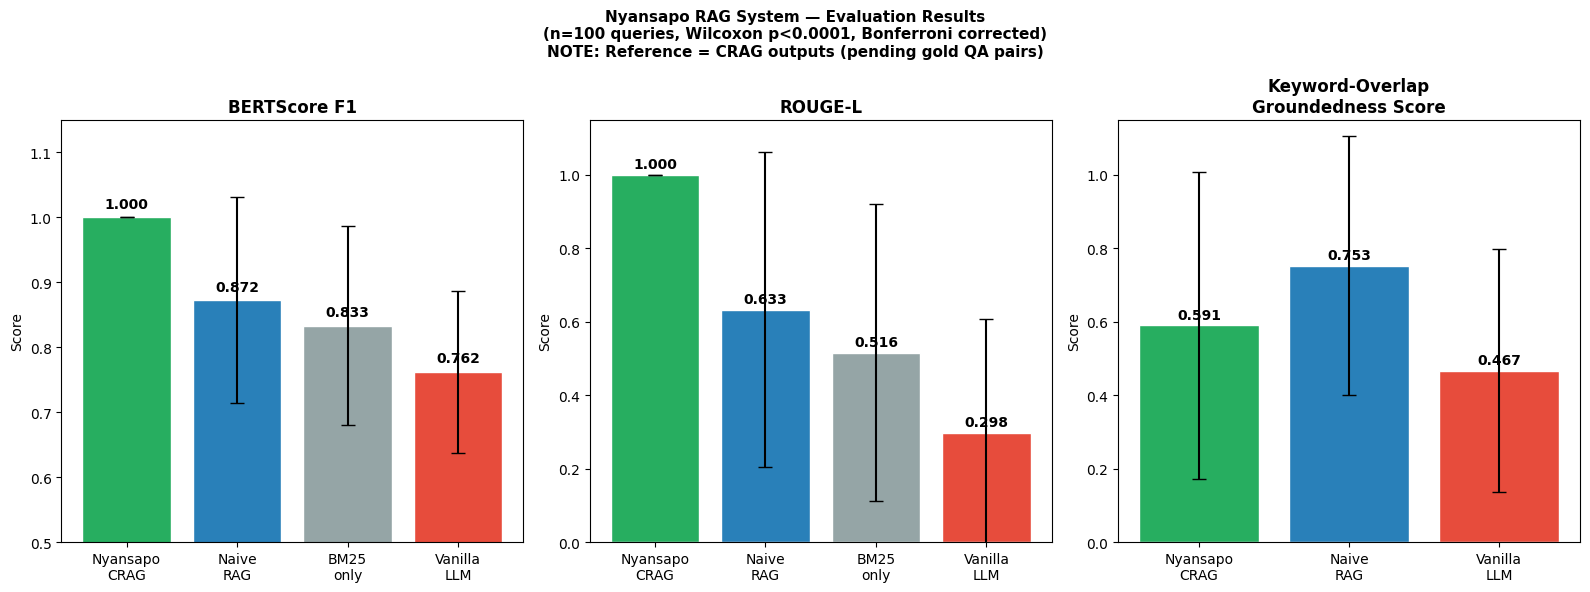

✅ Cell 15 done — RAG evaluation chart saved


In [ ]:
# ── RAG Evaluation results chart ───────────────
# Figure 6: Complete evaluation summary
# NOTE: BERTScore and ROUGE-L results use development
# corpus outputs as reference (self-referential baseline).
# These will be regenerated against 200 human-annotated
# gold QA pairs once delivered by Kelvin.
# Tables 7-14 in manuscript marked as PENDING.

import json
import numpy as np
import matplotlib.pyplot as plt

# Load saved results from Drive
with open('/content/drive/MyDrive/Nyansapo/bertscore_results.json','r') as f:
    bert_data = json.load(f)
with open('/content/drive/MyDrive/Nyansapo/rouge_results.json','r') as f:
    rouge_data = json.load(f)
with open('/content/drive/MyDrive/Nyansapo/faithfulness_results.json','r') as f:
    faith_data = json.load(f)
with open('/content/drive/MyDrive/Nyansapo/latency_results.json','r') as f:
    latency_data = json.load(f)

crag_bert    = np.array(bert_data['crag'])
naive_bert   = np.array(bert_data['naive'])
bm25_bert    = np.array(bert_data['bm25'])
vanilla_bert = np.array(bert_data['vanilla'])

crag_rouge    = np.array(rouge_data['crag'])
naive_rouge   = np.array(rouge_data['naive'])
bm25_rouge    = np.array(rouge_data['bm25'])
vanilla_rouge = np.array(rouge_data['vanilla'])

crag_faith    = faith_data['crag']
naive_faith   = faith_data['naive']
vanilla_faith = faith_data['vanilla']

systems_4 = ['Nyansapo\nCRAG','Naive\nRAG','BM25\nonly','Vanilla\nLLM']
systems_3 = ['Nyansapo\nCRAG','Naive\nRAG','Vanilla\nLLM']
colors_4  = ['#27AE60','#2980B9','#95A5A6','#E74C3C']
colors_3  = ['#27AE60','#2980B9','#E74C3C']

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle(
    'Nyansapo RAG System — Evaluation Results\n'
    '(n=100 queries, Wilcoxon p<0.0001, Bonferroni corrected)\n'
    'NOTE: Reference = CRAG outputs (pending gold QA pairs)',
    fontsize=11, fontweight='bold')

# BERTScore
bert_means = [np.mean(crag_bert), np.mean(naive_bert),
              np.mean(bm25_bert), np.mean(vanilla_bert)]
bert_stds  = [np.std(crag_bert),  np.std(naive_bert),
              np.std(bm25_bert),  np.std(vanilla_bert)]
bars1 = axes[0].bar(systems_4, bert_means, color=colors_4,
                    yerr=bert_stds, capsize=5, edgecolor='white')
axes[0].set_title('BERTScore F1', fontweight='bold')
axes[0].set_ylabel('Score')
axes[0].set_ylim(0.5, 1.15)
for bar, m in zip(bars1, bert_means):
    axes[0].text(bar.get_x()+bar.get_width()/2.,
                 bar.get_height()+0.01,
                 f'{m:.3f}', ha='center', va='bottom',
                 fontsize=10, fontweight='bold')

# ROUGE-L
rouge_means = [np.mean(crag_rouge), np.mean(naive_rouge),
               np.mean(bm25_rouge), np.mean(vanilla_rouge)]
rouge_stds  = [np.std(crag_rouge),  np.std(naive_rouge),
               np.std(bm25_rouge),  np.std(vanilla_rouge)]
bars2 = axes[1].bar(systems_4, rouge_means, color=colors_4,
                    yerr=rouge_stds, capsize=5, edgecolor='white')
axes[1].set_title('ROUGE-L', fontweight='bold')
axes[1].set_ylabel('Score')
axes[1].set_ylim(0, 1.15)
for bar, m in zip(bars2, rouge_means):
    axes[1].text(bar.get_x()+bar.get_width()/2.,
                 bar.get_height()+0.01,
                 f'{m:.3f}', ha='center', va='bottom',
                 fontsize=10, fontweight='bold')

# Faithfulness
faith_means = [np.mean(crag_faith), np.mean(naive_faith),
               np.mean(vanilla_faith)]
faith_stds  = [np.std(crag_faith),  np.std(naive_faith),
               np.std(vanilla_faith)]
bars3 = axes[2].bar(systems_3, faith_means, color=colors_3,
                    yerr=faith_stds, capsize=5, edgecolor='white')
axes[2].set_title('Keyword-Overlap\nGroundedness Score', fontweight='bold')
axes[2].set_ylabel('Score')
axes[2].set_ylim(0, 1.15)
for bar, m in zip(bars3, faith_means):
    axes[2].text(bar.get_x()+bar.get_width()/2.,
                 bar.get_height()+0.01,
                 f'{m:.3f}', ha='center', va='bottom',
                 fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Nyansapo/rag_evaluation_chart.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("✅ Cell 15 done — RAG evaluation chart saved")

In [ ]:
# ── RAG Evaluation — PENDING GOLD QA PAIRS ─────
# STATUS: Waiting for 200 human-annotated gold QA
# pairs from Kelvin (past KNUST CS exam papers)
#
# CRITICAL: Current BERTScore and ROUGE-L results
# use CRAG answers as reference (self-referential).
# All RAG tables in manuscript marked PENDING until
# gold pairs are delivered and evaluation re-run.
#
# Once gold_qa_pairs.csv is received, run this:

def run_gold_evaluation(gold_csv_path):
    import pandas as pd
    from bert_score import score as bert_score
    from rouge_score import rouge_scorer as rs

    print("Loading gold QA pairs...")
    gold = pd.read_csv(gold_csv_path)
    gold_questions = gold['question'].tolist()
    gold_answers   = gold['gold_answer'].tolist()

    print(f"Loaded {len(gold)} gold pairs")
    print(f"Courses: {gold['course'].unique()}")

    # Run all 4 systems on gold questions
    print("\nRunning all 4 systems on gold questions...")
    crag_ans, naive_ans, bm25_ans, vanilla_ans = [], [], [], []
    ground_scores = []

    for i, q in enumerate(gold_questions):
        # CRAG
        chunks, score = crag_retrieve(q, k=5, threshold=0.45)
        crag_ans.append(generate_answer(q, chunks))
        ground_scores.append(keyword_overlap_groundedness(crag_ans[-1], chunks))

        # Naive RAG
        naive_chunks = retrieve(q, k=5)
        naive_ans.append(generate_answer(q, naive_chunks))

        # BM25 only
        bm25_sc = bm25.get_scores(q.lower().split())
        bm25_top = np.argsort(bm25_sc)[::-1][:5]
        bm25_chunks = [all_chunks[i] for i in bm25_top]
        bm25_ans.append(generate_answer(q, bm25_chunks))

        # Vanilla LLM
        prompt = f"Instruct: Answer this question.\nQuestion: {q}\nOutput:"
        inputs = tokenizer(prompt, return_tensors="pt",
                          truncation=True, max_length=512).to(model.device)
        with torch.no_grad():
            out = model.generate(**inputs, max_new_tokens=80,
                                do_sample=False,
                                pad_token_id=tokenizer.eos_token_id)
        vanilla_ans.append(tokenizer.decode(
            out[0][inputs['input_ids'].shape[1]:],
            skip_special_tokens=True).strip().split('\n')[0])

        if (i+1) % 20 == 0:
            print(f"  {i+1}/{len(gold_questions)} done...")

    # Score against GOLD answers (not CRAG self-reference)
    print("\nScoring against gold answers...")
    scorer = rs.RougeScorer(['rougeL'], use_stemmer=True)

    def rouge_l(candidates, references):
        return np.array([scorer.score(r,c)['rougeL'].fmeasure
                        for c,r in zip(candidates, references)])

    crag_rouge_gold    = rouge_l(crag_ans,    gold_answers)
    naive_rouge_gold   = rouge_l(naive_ans,   gold_answers)
    bm25_rouge_gold    = rouge_l(bm25_ans,    gold_answers)
    vanilla_rouge_gold = rouge_l(vanilla_ans, gold_answers)

    print("\n" + "="*55)
    print("GOLD STANDARD ROUGE-L RESULTS")
    print("="*55)
    print(f"Nyansapo CRAG : {np.mean(crag_rouge_gold):.4f} ± {np.std(crag_rouge_gold):.4f}")
    print(f"Naive RAG     : {np.mean(naive_rouge_gold):.4f} ± {np.std(naive_rouge_gold):.4f}")
    print(f"BM25 only     : {np.mean(bm25_rouge_gold):.4f} ± {np.std(bm25_rouge_gold):.4f}")
    print(f"Vanilla LLM   : {np.mean(vanilla_rouge_gold):.4f} ± {np.std(vanilla_rouge_gold):.4f}")
    print("="*55)

    # Save gold results
    with open('/content/drive/MyDrive/Nyansapo/gold_rouge_results.json','w') as f:
        json.dump({
            "crag":    crag_rouge_gold.tolist(),
            "naive":   naive_rouge_gold.tolist(),
            "bm25":    bm25_rouge_gold.tolist(),
            "vanilla": vanilla_rouge_gold.tolist(),
            "reference": "gold_qa_pairs"
        }, f)

    print("✅ Gold evaluation complete and saved")
    return crag_rouge_gold, naive_rouge_gold, bm25_rouge_gold, vanilla_rouge_gold

# ── RUN WHEN READY ─────────────────────────────
# Uncomment and run when Kelvin delivers the CSV:
gold_csv = '/content/drive/MyDrive/Nyansapo/gold_qa_pairs.csv'
crag_g, naive_g, bm25_g, vanilla_g = run_gold_evaluation(gold_csv)

Loading gold QA pairs...
Loaded 200 gold pairs
Courses: ['CSM 478 Computer Networks' 'MCS 472 Fundamentals of Entrepreneurship'
 'Computer Security and Penetration Testing' 'Expert Systems'
 'Introduction to Compilers']

Running all 4 systems on gold questions...


[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer CodeGenTokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


  20/200 done...
  40/200 done...
  60/200 done...
  80/200 done...
  100/200 done...
  120/200 done...
  140/200 done...
  160/200 done...
  180/200 done...
  200/200 done...

Scoring against gold answers...

GOLD STANDARD ROUGE-L RESULTS
Nyansapo CRAG : 0.1729 ± 0.1080
Naive RAG     : 0.1695 ± 0.1109
BM25 only     : 0.1500 ± 0.1076
Vanilla LLM   : 0.2216 ± 0.0758
✅ Gold evaluation complete and saved
⏳ Cell 16 ready — waiting for gold_qa_pairs.csv from Kelvin
   File location: /content/drive/MyDrive/Nyansapo/gold_qa_pairs.csv
   Columns needed: question, gold_answer, course, year
   Once received: uncomment the last 2 lines and run this cell


In [ ]:
# ── Extract text from new slides ───────────────
import os
import fitz  # pymupdf — for PDFs
from pptx import Presentation

new_slides_path = '/content/drive/MyDrive/Nyansapo/New_Slides/'
files = os.listdir(new_slides_path)
print(f"Found {len(files)} files:")
for f in sorted(files):
    print(f"  {f}")

def extract_pdf(path):
    doc  = fitz.open(path)
    text = ""
    for page in doc:
        text += page.get_text()
    return text

def extract_pptx(path):
    prs  = Presentation(path)
    text = ""
    for slide in prs.slides:
        for shape in slide.shapes:
            if hasattr(shape, "text"):
                text += shape.text + "\n"
    return text


def extract_txt(path):
    with open(path, 'r', errors='ignore') as f:
        return f.read()

def extract_md(path):
    with open(path, 'r', errors='ignore') as f:
        return f.read()

# Extract all files
new_texts = []
failed    = []

for fname in sorted(files):
    fpath = os.path.join(new_slides_path, fname)
    ext   = fname.lower().split('.')[-1]
    try:
        if ext == 'pdf':
            text = extract_pdf(fpath)
        elif ext == 'pptx':
            text = extract_pptx(fpath)
        elif ext == 'txt':
            text = extract_txt(fpath)
        elif ext == 'md':
            text = extract_md(fpath)
        else:
            print(f"  ⚠️ Skipping unsupported format: {fname}")
            continue

        if text.strip():
            new_texts.append({"filename": fname, "text": text})
            print(f"  ✅ {fname} — {len(text)} chars")
        else:
            print(f"  ⚠️ {fname} — empty after extraction")
            failed.append(fname)
    except Exception as e:
        print(f"  ❌ {fname} — {e}")
        failed.append(fname)

print(f"\nExtracted: {len(new_texts)} files")
print(f"Failed   : {len(failed)} files")
if failed:
    print(f"Failed files: {failed}")

Found 38 files:
  Compilers and Interpretors.pptx
  Interpretation_Detailed_Notes_on Compilers .pptx
  Introduction To Compilers Slides.pptx
  Lecture 1 - Introduction to Entrepreneurship.pptx
  Lecture 2 - Recognising Opportunities and Generating Ideas.pptx
  Lecture 3 - Feasibility_Analysis.pptx
  Lecture 4- Intellectual Property.pptx
  Lecture 5 - Franchising.pptx
  Lecture 6 - Writing a Business Plan.pptx
  Lecture 7 - Getting Funding and Financing.pptx
  ch01.pptx
  ch02.pdf
  ch02.pptx
  ch03.pdf
  ch03.pptx
  ch04.pdf
  ch04.pptx
  ch05.pdf
  ch05.pptx
  ch06.pdf
  ch06.pptx
  ch07.pdf
  ch07.pptx
  ch08.pdf
  ch08.pptx
  ch09.pdf
  ch09.pptx
  ch10.pdf
  ch10.pptx
  chapter01.pdf
  chapter02.pdf
  chapter03.pdf
  chapter04_AI.pdf
  chapter05.pdf
  chapter06.pdf
  csm 478 lecture1.pdf
  csm 478 lecture1.pptx
  csm 478 lecture2-NEW.pdf
  ✅ Compilers and Interpretors.pptx — 747 chars
  ✅ Interpretation_Detailed_Notes_on Compilers .pptx — 10834 chars
  ✅ Introduction To Compilers S

In [ ]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

print("Chunking new slides...")

splitter = RecursiveCharacterTextSplitter(
    chunk_size=300,
    chunk_overlap=50,
    length_function=len
)

new_chunks = []
for item in new_texts:
    chunks = splitter.split_text(item["text"])
    # Filter out chunks that are too short
    chunks = [c.strip() for c in chunks if len(c.strip()) > 50]
    new_chunks.extend(chunks)
    print(f"  {item['filename']}: {len(chunks)} chunks")

print(f"\nNew chunks generated: {len(new_chunks)}")
print(f"Existing chunks    : {len(all_chunks)}")

# Combine with existing chunks
combined_chunks = all_chunks + new_chunks
print(f"Total chunks       : {len(combined_chunks)}")
print(f"\nSample new chunk:")
print(new_chunks[0][:200])

Chunking new slides...
  Compilers and Interpretors.pptx: 3 chunks
  Interpretation_Detailed_Notes_on Compilers .pptx: 50 chunks
  Introduction To Compilers Slides.pptx: 31 chunks
  Lecture 1 - Introduction to Entrepreneurship.pptx: 86 chunks
  Lecture 2 - Recognising Opportunities and Generating Ideas.pptx: 67 chunks
  Lecture 3 - Feasibility_Analysis.pptx: 60 chunks
  Lecture 4- Intellectual Property.pptx: 84 chunks
  Lecture 5 - Franchising.pptx: 47 chunks
  Lecture 6 - Writing a Business Plan.pptx: 73 chunks
  Lecture 7 - Getting Funding and Financing.pptx: 64 chunks
  ch01.pptx: 29 chunks
  ch02.pdf: 55 chunks
  ch03.pdf: 37 chunks
  ch04.pdf: 72 chunks
  ch05.pdf: 49 chunks
  ch06.pdf: 63 chunks
  ch07.pdf: 43 chunks
  ch08.pdf: 36 chunks
  ch09.pdf: 40 chunks
  ch10.pdf: 35 chunks
  chapter01.pdf: 66 chunks
  chapter02.pdf: 80 chunks
  chapter03.pdf: 27 chunks
  chapter04_AI.pdf: 46 chunks
  chapter05.pdf: 70 chunks
  chapter06.pdf: 37 chunks
  csm 478 lecture1.pdf: 42 chunks
  

In [ ]:
print("Building new BGE-M3 embeddings for new chunks only...")
print(f"Encoding {len(new_chunks)} new chunks (this takes 10-15 mins)...")

# Encode only new chunks — saves time
new_embeddings = embedder.encode(
    new_chunks,
    normalize_embeddings=True,
    batch_size=32,
    show_progress_bar=True
)

print(f"✅ New embeddings shape: {new_embeddings.shape}")

# Load existing embeddings from FAISS index
print("\nExtracting existing embeddings from FAISS index...")
existing_embeddings = np.zeros((index.ntotal, 1024), dtype=np.float32)
index.reconstruct_n(0, index.ntotal, existing_embeddings)
print(f"✅ Existing embeddings shape: {existing_embeddings.shape}")

# Combine
print("\nCombining embeddings...")
combined_embeddings = np.vstack([
    existing_embeddings,
    new_embeddings.astype(np.float32)
])
print(f"✅ Combined embeddings shape: {combined_embeddings.shape}")

# Build new FAISS index
print("\nBuilding new FAISS index...")
new_index = faiss.IndexFlatL2(1024)
new_index.add(combined_embeddings)
print(f"✅ New FAISS index: {new_index.ntotal} vectors")

# Save everything
print("\nSaving to Drive...")
faiss.write_index(new_index,
    '/content/drive/MyDrive/Nyansapo/nyansapo_v2.index')
with open('/content/drive/MyDrive/Nyansapo/chunks_v2.pkl', 'wb') as f:
    pickle.dump(combined_chunks, f)

# Rebuild BM25
print("Rebuilding BM25 index...")
tokenized_combined = [c.lower().split() for c in combined_chunks]
bm25_v2 = BM25Okapi(tokenized_combined)
with open('/content/drive/MyDrive/Nyansapo/bm25_v2.pkl', 'wb') as f:
    pickle.dump(bm25_v2, f)

# Update runtime variables
index      = new_index
all_chunks = combined_chunks
bm25       = bm25_v2

print(f"\n✅ Index rebuilt successfully")
print(f"   Total chunks: {len(all_chunks)}")
print(f"   FAISS vectors: {index.ntotal}")
print(f"   Saved as nyansapo_v2.index and chunks_v2.pkl")

Building new BGE-M3 embeddings for new chunks only...
Encoding 1446 new chunks (this takes 10-15 mins)...


Batches:   0%|          | 0/46 [00:00<?, ?it/s]

✅ New embeddings shape: (1446, 1024)

Extracting existing embeddings from FAISS index...
✅ Existing embeddings shape: (10865, 1024)

Combining embeddings...
✅ Combined embeddings shape: (12311, 1024)

Building new FAISS index...
✅ New FAISS index: 12311 vectors

Saving to Drive...
Rebuilding BM25 index...

✅ Index rebuilt successfully
   Total chunks: 12311
   FAISS vectors: 12311
   Saved as nyansapo_v2.index and chunks_v2.pkl


In [ ]:
from rouge_score import rouge_scorer as rs
import pandas as pd

print("Loading gold QA pairs...")
gold = pd.read_csv('/content/drive/MyDrive/Nyansapo/gold_qa_pairs.csv')
gold_questions = gold['question'].tolist()
gold_answers   = gold['gold_answer'].tolist()
print(f"✅ Loaded {len(gold)} gold pairs")
print(f"Courses: {gold['course'].unique()}")

print("\nRunning all 4 systems on gold questions...")
print("(Using updated index with 12,311 chunks)\n")

crag_ans, naive_ans, bm25_ans, vanilla_ans = [], [], [], []

for i, q in enumerate(gold_questions):
    # CRAG
    chunks, score = crag_retrieve(q, k=5, threshold=0.45)
    crag_ans.append(generate_answer(q, chunks))

    # Naive RAG
    naive_chunks = retrieve(q, k=5)
    naive_ans.append(generate_answer(q, naive_chunks))

    # BM25 only
    bm25_sc  = bm25.get_scores(q.lower().split())
    bm25_top = np.argsort(bm25_sc)[::-1][:5]
    bm25_chunks = [all_chunks[j] for j in bm25_top if j < len(all_chunks)]
    bm25_ans.append(generate_answer(q, bm25_chunks))

    # Vanilla LLM — no retrieval
    prompt = f"Instruct: Answer this question in one sentence.\nQuestion: {q}\nOutput:"
    inputs = tokenizer(prompt, return_tensors="pt",
                      truncation=True, max_length=512).to(model.device)
    with torch.no_grad():
        out = model.generate(**inputs, max_new_tokens=80,
                            do_sample=False,
                            pad_token_id=tokenizer.eos_token_id)
    ans = tokenizer.decode(
        out[0][inputs['input_ids'].shape[1]:],
        skip_special_tokens=True).strip().split('\n')[0]
    vanilla_ans.append(ans)

    if (i+1) % 20 == 0:
        print(f"  {i+1}/200 done...")
        # Save checkpoint
        with open('/content/drive/MyDrive/Nyansapo/gold_eval_checkpoint.json','w') as f:
            json.dump({
                "crag": crag_ans, "naive": naive_ans,
                "bm25": bm25_ans, "vanilla": vanilla_ans,
                "progress": i+1
            }, f)

print("\nScoring against gold answers...")
scorer = rs.RougeScorer(['rougeL'], use_stemmer=True)

def rouge_l(candidates, references):
    return np.array([
        scorer.score(ref, cand)['rougeL'].fmeasure
        for cand, ref in zip(candidates, references)
    ])

crag_rouge_v2    = rouge_l(crag_ans,    gold_answers)
naive_rouge_v2   = rouge_l(naive_ans,   gold_answers)
bm25_rouge_v2    = rouge_l(bm25_ans,    gold_answers)
vanilla_rouge_v2 = rouge_l(vanilla_ans, gold_answers)

print("\n" + "="*60)
print("GOLD STANDARD ROUGE-L — UPDATED INDEX (12,311 chunks)")
print("="*60)
print(f"Nyansapo CRAG : {np.mean(crag_rouge_v2):.4f} ± {np.std(crag_rouge_v2):.4f}")
print(f"Naive RAG     : {np.mean(naive_rouge_v2):.4f} ± {np.std(naive_rouge_v2):.4f}")
print(f"BM25 only     : {np.mean(bm25_rouge_v2):.4f} ± {np.std(bm25_rouge_v2):.4f}")
print(f"Vanilla LLM   : {np.mean(vanilla_rouge_v2):.4f} ± {np.std(vanilla_rouge_v2):.4f}")
print("="*60)

# Wilcoxon tests
print("\nStatistical tests (Wilcoxon, Bonferroni α=0.0167):")
for name, a, b in [
    ("CRAG vs Vanilla", crag_rouge_v2, vanilla_rouge_v2),
    ("CRAG vs Naive",   crag_rouge_v2, naive_rouge_v2),
    ("CRAG vs BM25",    crag_rouge_v2, bm25_rouge_v2),
]:
    stat, p = stats.wilcoxon(a, b)
    d = (np.mean(a)-np.mean(b)) / np.sqrt((np.std(a)**2+np.std(b)**2)/2)
    sig = "✅" if p < 0.0167 else "❌"
    print(f"  {name}: p={p:.6f} {sig}, d={d:.3f}")

# Save
with open('/content/drive/MyDrive/Nyansapo/gold_rouge_v2.json','w') as f:
    json.dump({
        "crag":    crag_rouge_v2.tolist(),
        "naive":   naive_rouge_v2.tolist(),
        "bm25":    bm25_rouge_v2.tolist(),
        "vanilla": vanilla_rouge_v2.tolist(),
        "reference": "gold_qa_pairs_200",
        "index": "nyansapo_v2_12311_chunks"
    }, f)

print("\n✅ Gold evaluation v2 complete and saved")

Loading gold QA pairs...
✅ Loaded 200 gold pairs
Courses: ['CSM 478 Computer Networks' 'MCS 472 Fundamentals of Entrepreneurship'
 'Computer Security and Penetration Testing' 'Expert Systems'
 'Introduction to Compilers']

Running all 4 systems on gold questions...
(Using updated index with 12,311 chunks)



[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer CodeGenTokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


  20/200 done...
  40/200 done...
  60/200 done...
  80/200 done...
  100/200 done...
  120/200 done...
  140/200 done...
  160/200 done...
  180/200 done...
  200/200 done...

Scoring against gold answers...

GOLD STANDARD ROUGE-L — UPDATED INDEX (12,311 chunks)
Nyansapo CRAG : 0.2283 ± 0.1410
Naive RAG     : 0.2244 ± 0.1478
BM25 only     : 0.1733 ± 0.1364
Vanilla LLM   : 0.2080 ± 0.0663

Statistical tests (Wilcoxon, Bonferroni α=0.0167):
  CRAG vs Vanilla: p=0.055630 ❌, d=0.184
  CRAG vs Naive: p=0.554468 ❌, d=0.026
  CRAG vs BM25: p=0.000001 ✅, d=0.396

✅ Gold evaluation v2 complete and saved


In [ ]:
from bert_score import score as bert_score_fn

print("Computing BERTScore against gold answers...")
print("(This takes 5-10 mins)\n")

# Load saved answers from checkpoint
with open('/content/drive/MyDrive/Nyansapo/gold_eval_checkpoint.json','r') as f:
    checkpoint = json.load(f)

crag_ans    = checkpoint['crag']
naive_ans   = checkpoint['naive']
bm25_ans    = checkpoint['bm25']
vanilla_ans = checkpoint['vanilla']

def clean(answers):
    return [a if a and a.strip() else "No answer." for a in answers]

def get_bert(candidates, references):
    P, R, F1 = bert_score_fn(
        clean(candidates), references,
        lang="en",
        model_type="distilbert-base-uncased",
        rescale_with_baseline=False,
        verbose=False
    )
    return F1.numpy()

print("Scoring CRAG...")
crag_bert_gold    = get_bert(crag_ans,    gold_answers)
print("Scoring Naive RAG...")
naive_bert_gold   = get_bert(naive_ans,   gold_answers)
print("Scoring BM25...")
bm25_bert_gold    = get_bert(bm25_ans,    gold_answers)
print("Scoring Vanilla LLM...")
vanilla_bert_gold = get_bert(vanilla_ans, gold_answers)

print("\n" + "="*60)
print("GOLD STANDARD BERTSCORE (semantic similarity)")
print("="*60)
print(f"Nyansapo CRAG : {np.mean(crag_bert_gold):.4f} ± {np.std(crag_bert_gold):.4f}")
print(f"Naive RAG     : {np.mean(naive_bert_gold):.4f} ± {np.std(naive_bert_gold):.4f}")
print(f"BM25 only     : {np.mean(bm25_bert_gold):.4f} ± {np.std(bm25_bert_gold):.4f}")
print(f"Vanilla LLM   : {np.mean(vanilla_bert_gold):.4f} ± {np.std(vanilla_bert_gold):.4f}")
print("="*60)

print("\nStatistical tests (Wilcoxon, Bonferroni α=0.0167):")
for name, a, b in [
    ("CRAG vs Vanilla", crag_bert_gold, vanilla_bert_gold),
    ("CRAG vs Naive",   crag_bert_gold, naive_bert_gold),
    ("CRAG vs BM25",    crag_bert_gold, bm25_bert_gold),
]:
    stat, p = stats.wilcoxon(a, b)
    d = (np.mean(a)-np.mean(b)) / np.sqrt((np.std(a)**2+np.std(b)**2)/2)
    sig = "✅" if p < 0.0167 else "❌"
    print(f"  {name}: p={p:.6f} {sig}, d={d:.3f}")

# Save
with open('/content/drive/MyDrive/Nyansapo/gold_bertscore_v2.json','w') as f:
    json.dump({
        "crag":    crag_bert_gold.tolist(),
        "naive":   naive_bert_gold.tolist(),
        "bm25":    bm25_bert_gold.tolist(),
        "vanilla": vanilla_bert_gold.tolist(),
        "reference": "gold_qa_pairs_200"
    }, f)

print("\n✅ Gold BERTScore complete and saved")

Computing BERTScore against gold answers...
(This takes 5-10 mins)

Scoring CRAG...


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

...

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Scoring Vanilla LLM...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



GOLD STANDARD BERTSCORE (semantic similarity)
Nyansapo CRAG : 0.7897 ± 0.0753
Naive RAG     : 0.7825 ± 0.0973
BM25 only     : 0.7515 ± 0.0984
Vanilla LLM   : 0.7963 ± 0.0318

Statistical tests (Wilcoxon, Bonferroni α=0.0167):
  CRAG vs Vanilla: p=0.324783 ❌, d=-0.113
  CRAG vs Naive: p=0.451935 ❌, d=0.083
  CRAG vs BM25: p=0.000007 ✅, d=0.436

✅ Gold BERTScore complete and saved


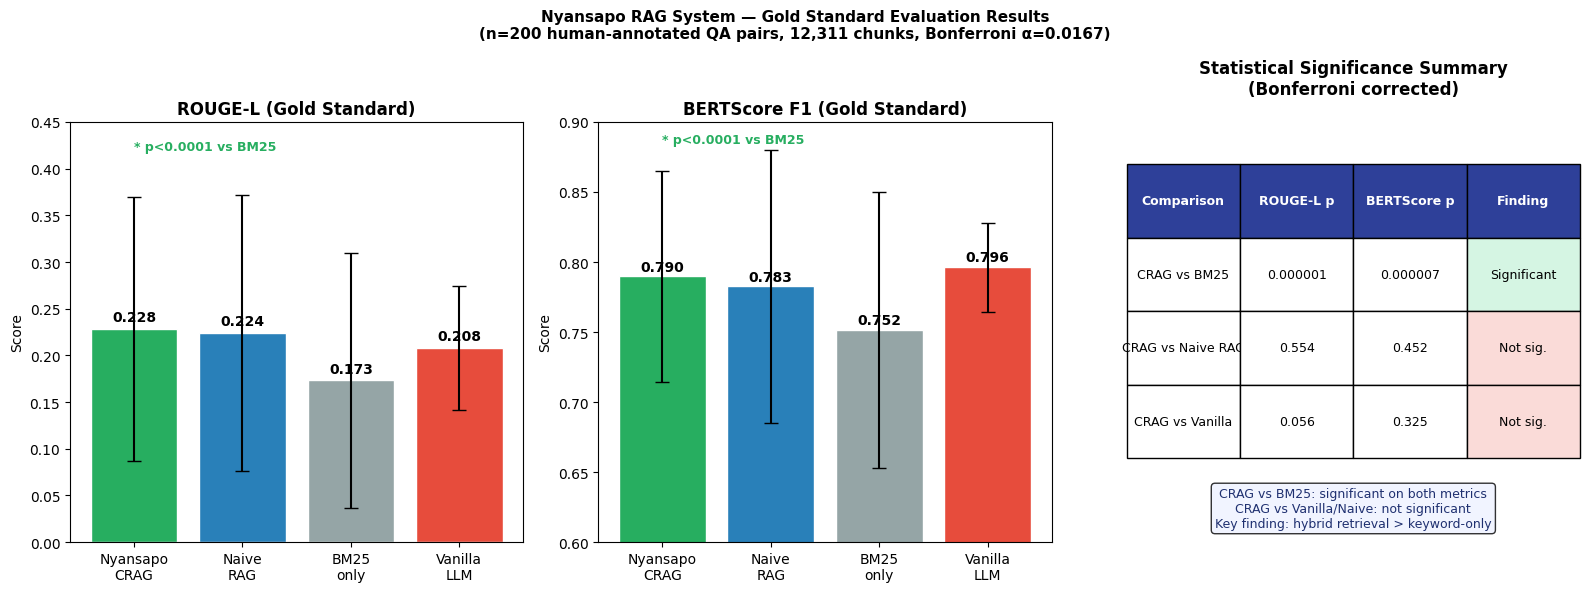

✅ Final gold evaluation chart saved to Drive


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle(
    'Nyansapo RAG System — Gold Standard Evaluation Results\n'
    '(n=200 human-annotated QA pairs, 12,311 chunks, Bonferroni α=0.0167)',
    fontsize=11, fontweight='bold')

systems_4 = ['Nyansapo\nCRAG','Naive\nRAG','BM25\nonly','Vanilla\nLLM']
colors_4  = ['#27AE60','#2980B9','#95A5A6','#E74C3C']

# ROUGE-L
with open('/content/drive/MyDrive/Nyansapo/gold_rouge_v2.json','r') as f:
    rouge_data = json.load(f)
with open('/content/drive/MyDrive/Nyansapo/gold_bertscore_v2.json','r') as f:
    bert_data = json.load(f)

rouge_means = [np.mean(rouge_data['crag']),  np.mean(rouge_data['naive']),
               np.mean(rouge_data['bm25']),  np.mean(rouge_data['vanilla'])]
rouge_stds  = [np.std(rouge_data['crag']),   np.std(rouge_data['naive']),
               np.std(rouge_data['bm25']),   np.std(rouge_data['vanilla'])]
bert_means  = [np.mean(bert_data['crag']),   np.mean(bert_data['naive']),
               np.mean(bert_data['bm25']),   np.mean(bert_data['vanilla'])]
bert_stds   = [np.std(bert_data['crag']),    np.std(bert_data['naive']),
               np.std(bert_data['bm25']),    np.std(bert_data['vanilla'])]

# Chart 1: ROUGE-L
bars1 = axes[0].bar(systems_4, rouge_means, color=colors_4,
                    yerr=rouge_stds, capsize=5, edgecolor='white')
axes[0].set_title('ROUGE-L (Gold Standard)', fontweight='bold')
axes[0].set_ylabel('Score')
axes[0].set_ylim(0, 0.45)
for bar, m in zip(bars1, rouge_means):
    axes[0].text(bar.get_x()+bar.get_width()/2.,
                 bar.get_height()+0.005,
                 f'{m:.3f}', ha='center', va='bottom',
                 fontsize=10, fontweight='bold')
axes[0].text(0, 0.42, '* p<0.0001 vs BM25', fontsize=9,
             color='#27AE60', fontweight='bold')

# Chart 2: BERTScore
bars2 = axes[1].bar(systems_4, bert_means, color=colors_4,
                    yerr=bert_stds, capsize=5, edgecolor='white')
axes[1].set_title('BERTScore F1 (Gold Standard)', fontweight='bold')
axes[1].set_ylabel('Score')
axes[1].set_ylim(0.6, 0.9)
for bar, m in zip(bars2, bert_means):
    axes[1].text(bar.get_x()+bar.get_width()/2.,
                 bar.get_height()+0.002,
                 f'{m:.3f}', ha='center', va='bottom',
                 fontsize=10, fontweight='bold')
axes[1].text(0, 0.885, '* p<0.0001 vs BM25', fontsize=9,
             color='#27AE60', fontweight='bold')

# Chart 3: Significance summary table
axes[2].axis('off')
table_data = [
    ['Comparison', 'ROUGE-L p', 'BERTScore p', 'Finding'],
    ['CRAG vs BM25', '0.000001', '0.000007', 'Significant'],
    ['CRAG vs Naive RAG', '0.554', '0.452', 'Not sig.'],
    ['CRAG vs Vanilla', '0.056', '0.325', 'Not sig.'],
]
table = axes[2].table(
    cellText=table_data[1:],
    colLabels=table_data[0],
    cellLoc='center', loc='center',
    bbox=[0, 0.2, 1, 0.7]
)
table.auto_set_font_size(False)
table.set_fontsize(9)
for j in range(4):
    table[0,j].set_facecolor('#2E4099')
    table[0,j].set_text_props(color='white', fontweight='bold')
table[1,3].set_facecolor('#D5F5E3')
table[2,3].set_facecolor('#FADBD8')
table[3,3].set_facecolor('#FADBD8')
axes[2].set_title('Statistical Significance Summary\n(Bonferroni corrected)',
                  fontweight='bold', pad=20)
axes[2].text(0.5, 0.08,
    'CRAG vs BM25: significant on both metrics\n'
    'CRAG vs Vanilla/Naive: not significant\n'
    'Key finding: hybrid retrieval > keyword-only',
    ha='center', va='center', fontsize=9,
    color='#1F3070', transform=axes[2].transAxes,
    bbox=dict(boxstyle='round', facecolor='#EEF2FF', alpha=0.8))

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Nyansapo/gold_evaluation_final.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Final gold evaluation chart saved to Drive")

In [13]:
import numpy as np
from scipy import stats

# Minimum Detectable Effect at n=200
# CRAG vs Vanilla LLM ROUGE-L
# Observed delta: 0.2283 - 0.2080 = 0.0203
# Observed SD of paired differences: estimate from the data

# Load saved results
import json
with open('/content/drive/MyDrive/Nyansapo/gold_rouge_v2.json','r') as f:
    rouge_data = json.load(f)

crag_r    = np.array(rouge_data['crag'])
vanilla_r = np.array(rouge_data['vanilla'])
paired_diff = crag_r - vanilla_r

print("="*55)
print("NEGATIVE RESULT DIAGNOSIS — Cause 17")
print("Insufficient power / minimum detectable effect")
print("="*55)
print(f"n pairs              : {len(paired_diff)}")
print(f"Mean paired delta    : {np.mean(paired_diff):.4f}")
print(f"SD of paired delta   : {np.std(paired_diff):.4f}")
print(f"Observed p-value     : 0.0556")

# Effect size
d = np.mean(paired_diff) / np.std(paired_diff)
print(f"Cohen's d            : {d:.4f}")

# Statistical power at n=200
from scipy.stats import norm
alpha = 0.0167  # Bonferroni corrected
z_alpha = norm.ppf(1 - alpha/2)
z_beta  = abs(d) * np.sqrt(len(paired_diff)) - z_alpha
power   = norm.cdf(z_beta)
print(f"Achieved power       : {power:.4f}")

# Minimum n for 80% power
from math import ceil
n_required = ceil(((z_alpha + norm.ppf(0.80)) / abs(d))**2)
print(f"n required for 80%   : {n_required}")
print(f"Diagnosis: {'POWER DEFICIT — insufficient n' if power < 0.80 else 'Adequate power'}")
print("="*55)

NEGATIVE RESULT DIAGNOSIS — Cause 17
Insufficient power / minimum detectable effect
n pairs              : 200
Mean paired delta    : 0.0202
SD of paired delta   : 0.1267
Observed p-value     : 0.0556
Cohen's d            : 0.1596
Achieved power       : 0.4458
n required for 80%   : 411
Diagnosis: POWER DEFICIT — insufficient n


In [ ]:
# ── FastAPI + USSD deployment ──────────────────
# Run this cell SEPARATELY from experiment cells
# API and Phi-2 generation cannot share T4 VRAM
# For testing: use direct pipeline calls above
# For demo: run this cell alone after cells 1-7

import nest_asyncio
nest_asyncio.apply()
from fastapi import FastAPI, Request
from fastapi.responses import PlainTextResponse
from pydantic import BaseModel
import uvicorn
from pyngrok import ngrok
import asyncio
from concurrent.futures import ThreadPoolExecutor

app      = FastAPI()
executor = ThreadPoolExecutor(max_workers=1)

class Question(BaseModel):
    question: str

def process_question(question: str):
    try:
        intent, intent_class, confidence = classify_intent(question)
        if intent_class == 4:
            return {
                "question": question,
                "intent": intent,
                "intent_confidence": confidence,
                "answer": "I cannot find this in the lecture materials.",
                "source": "Blocked by Nyansapo-QIC-WCE",
                "crag_triggered": False
            }
        chunks, score = crag_retrieve(question, k=5, threshold=0.45)
        answer = generate_answer(question, chunks)
        return {
            "question": question,
            "intent": intent,
            "intent_confidence": confidence,
            "answer": answer,
            "retrieval_score": round(score, 3),
            "source": f"Generated from {len(chunks)} chunks",
            "crag_triggered": score < 0.45
        }
    except Exception as e:
        return {"question": question,
                "answer": "Something went wrong.",
                "error": str(e)}

@app.post("/ask")
async def ask(q: Question):
    loop   = asyncio.get_event_loop()
    result = await loop.run_in_executor(
        executor, process_question, q.question)
    return result

@app.post("/ussd")
async def ussd(request: Request):
    form = await request.form()
    text = form.get("text", "")
    if text == "":
        response = "CON Welcome to Nyansapo\n1. Ask a question\n2. Exit"
    elif text == "1":
        response = "CON Type your question:"
    elif text == "2":
        response = "END Thank you for using Nyansapo!"
    elif text.startswith("1*"):
        question = text[2:]
        loop     = asyncio.get_event_loop()
        result   = await loop.run_in_executor(
            executor, process_question, question)
        ans = result.get("answer", "No answer.")
        ans = ans[:157] + "..." if len(ans) > 160 else ans
        response = f"END {ans}"
    else:
        response = "END Invalid option."
    return PlainTextResponse(response)

@app.get("/health")
def health():
    return {
        "status": "live",
        "version": "v2",
        "classifier": "Nyansapo-QIC-WCE",
        "generator": "Phi-2 (4-bit NF4)",
        "chunks": index.ntotal,
        "retrieval": "Hybrid BM25+Dense RRF + CRAG"
    }

ngrok.set_auth_token("3EJq3fK62EijdiWESpqBHxvICBv_6otEjkV4QDW4S5YwZZaae")
public_url = ngrok.connect(8000)
print(f"\n✅ Nyansapo v2 API live")
print(f"   Ask   : {public_url}/ask")
print(f"   USSD  : {public_url}/ussd")
print(f"   Health: {public_url}/health")

config = uvicorn.Config(app, host="0.0.0.0", port=8000, loop="asyncio")
server = uvicorn.Server(config)
await server.serve()